# 05 - Feature Importance Analysis with SHAP values

Dataset: `engineered_dataset.csv`
Model: Logistic Regression (retained from notebook 04)

### Context

Notebook 04 established that **Logistic Regression with `class_weight="balanced"`** is the production model
on the 10-year threshold (AUC = 0.758), and computed permutation importance to rank features.

This notebook goes further in interpretability with two complementary methods:
1. **Standardised LR coefficients** — direct readout of the linear model's learned weights after scaling features to unit variance; shows direction (positive/negative) and relative magnitude
2. **SHAP values (LinearExplainer)** — exact Shapley decomposition per observation; shows both the global importance ranking and the per-instance direction of each feature's contribution

The goal is to identify features with negligible contribution, which will be pruned in notebook 06.


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')


## Load data & retrain on 120-month threshold

We retrain Logistic Regression with identical hyperparameters on the full feature set.
Features are standardised before computing coefficients so that magnitudes are comparable across scales.


In [2]:
df = pd.read_csv("../src/data/processed/engineered_dataset.csv")

THRESHOLD_MONTHS = 120  # 10 years

df["long_lasting"] = (df["relationship_longevity_months"] >= THRESHOLD_MONTHS).astype(int)

n_pos = df["long_lasting"].sum()
n_tot = len(df)
print(f"Threshold : {THRESHOLD_MONTHS} months ({THRESHOLD_MONTHS/12:.0f} years)")
print(f"Class distribution:")
print(df["long_lasting"].value_counts(normalize=True).round(4))
print(f"\n→ {n_pos:,} positives out of {n_tot:,} ({100*n_pos/n_tot:.2f}%)")


Threshold : 120 months (10 years)
Class distribution:
long_lasting
0    0.9906
1    0.0094
Name: proportion, dtype: float64

→ 940 positives out of 100,000 (0.94%)


In [3]:
X = df.drop(
    columns=["relationship_longevity_months", "relationship_longevity_years", "long_lasting"],
    errors="ignore"
)
y = df["long_lasting"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"Features   : {X.shape[1]}")
print(f"ROC-AUC    : {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")


Train size : 70000
Test size  : 30000
Features   : 16
ROC-AUC    : 0.7578


## SHAP Values (LinearExplainer)

In [4]:
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

explainer   = shap.LinearExplainer(model, X_test_df)
shap_values = explainer.shap_values(X_test_df)

print(f"SHAP values shape: {shap_values.shape}")


SHAP values shape: (30000, 16)


### Beeswarm plot — SHAP value distribution per feature

Each dot = one test set observation.
- Horizontal position = SHAP value (impact on the predicted log-odds)
- Colour = original feature value (red = high, blue = low)
- Features ranked by global importance (mean |SHAP|)


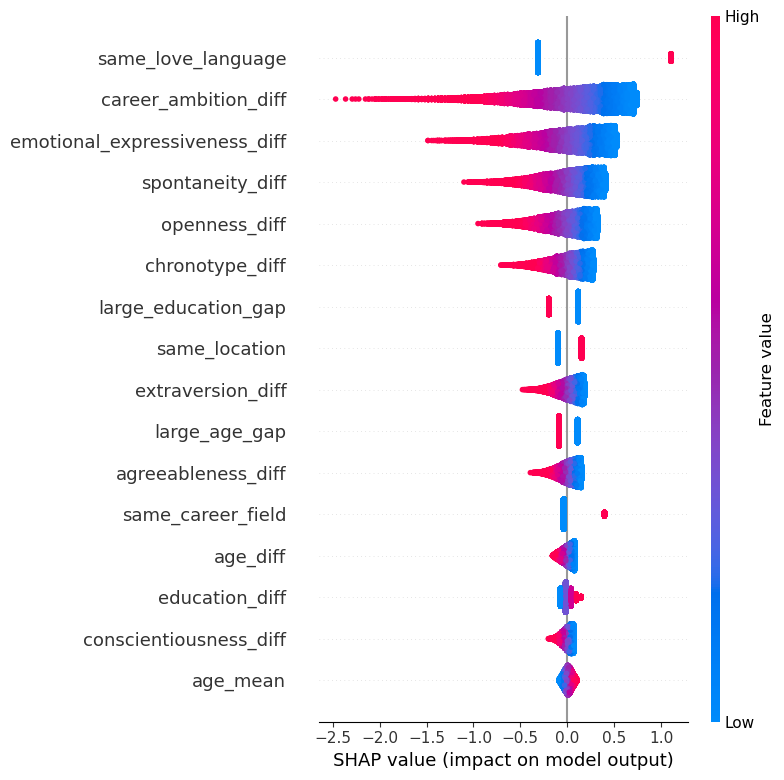

In [5]:
shap.summary_plot(shap_values, X_test_df, max_display=16)


### Bar plot — global feature importance (mean |SHAP|)

Concise summary: mean absolute SHAP value across all test observations.
Directly comparable to permutation importance, but computed as a direct contribution rather than an AUC degradation.


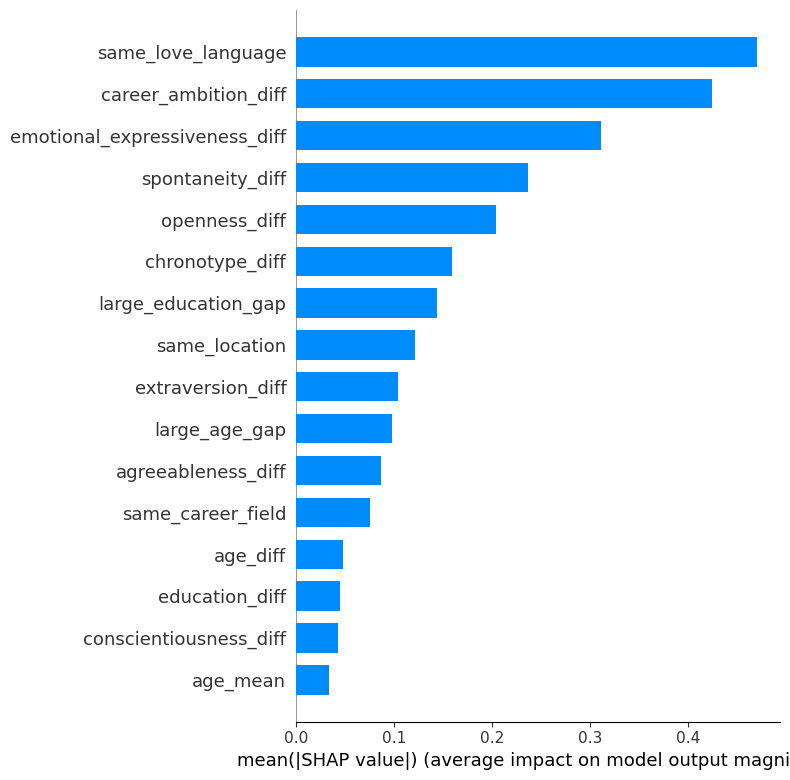

In [6]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=16)


### SHAP values — interpretation

**Reading the beeswarm:**

- **`same_love_language`**: the most decisive factor by far. When two people share the same love language (red dots, right side), it strongly increases the predicted probability of lasting 10+ years. When they don't (blue dots, left side), it decreases it. The two clusters are perfectly separated — no ambiguity.

- **`career_ambition_diff`** and **`emotional_expressiveness_diff`**: the more different two partners are on career ambition or emotional expressiveness, the more it hurts their chances. The wide Gaussian spread shows this effect varies a lot from couple to couple — some are barely affected, others heavily penalised.

- **`spontaneity_diff`, `openness_diff`, `chronotype_diff`**: same story, just a bit weaker. Across all personality difference features, the pattern is consistent: **similarity helps, dissimilarity hurts** — no exception.

- **`large_education_gap`**, **`same_location`**, **`extraversion_diff`**, **`same_career_field`, `agreeableness_diff`,`large_age_gap`**: small but non-zero signal — kept in the model.

- **`conscientiousness_diff`, `age_diff`, `education_diff`, `age_mean`**: all 4 are flat and clustered around SHAP = 0 across the entire test set — the model essentially ignores them. These can be dropped with no hesitation.

## Permutation Importance

Permutation importance measures the **ROC-AUC drop** when a feature's values are randomly shuffled on the test set (30 repeats for stability). Unlike SHAP, it is purely empirical and model-agnostic.

Both methods should agree on the ranking — if they do, the signal is robust.


                      Feature  Importance_mean  Importance_std
           same_love_language         0.090108        0.007802
         career_ambition_diff         0.044788        0.008911
emotional_expressiveness_diff         0.042968        0.006080
             spontaneity_diff         0.021637        0.004348
                openness_diff         0.010279        0.003536
              chronotype_diff         0.008442        0.002528
           agreeableness_diff         0.003429        0.001705
            extraversion_diff         0.003295        0.001812
                same_location         0.002849        0.001713
          large_education_gap         0.002546        0.002138
                large_age_gap         0.001953        0.001614
       conscientiousness_diff         0.001547        0.000768
            same_career_field         0.001463        0.001941
               education_diff         0.001405        0.000731
                     age_diff         0.000564        0

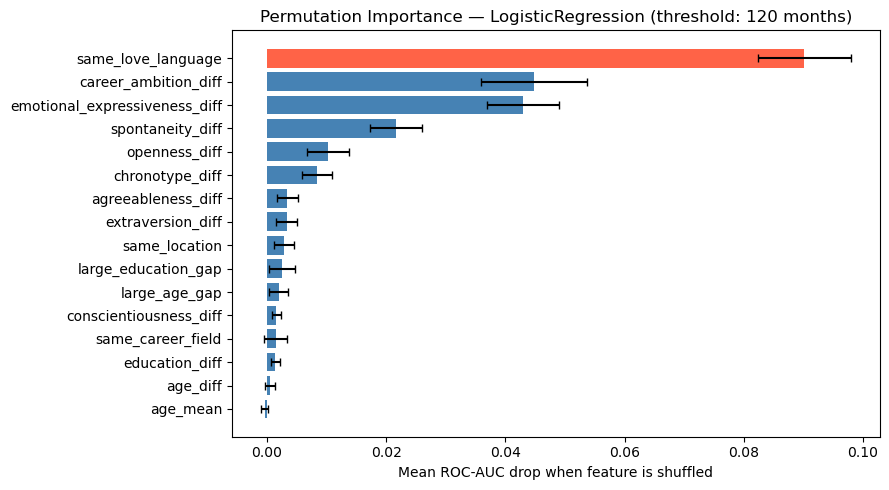

In [7]:
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature":         X.columns,
    "Importance_mean": perm.importances_mean,
    "Importance_std":  perm.importances_std
}).sort_values("Importance_mean", ascending=False).reset_index(drop=True)

print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tomato" if f == "same_love_language" else "steelblue"
          for f in perm_df["Feature"][::-1]]
ax.barh(
    perm_df["Feature"][::-1],
    perm_df["Importance_mean"][::-1],
    xerr=perm_df["Importance_std"][::-1],
    color=colors, capsize=3
)
ax.set_xlabel("Mean ROC-AUC drop when feature is shuffled")
ax.set_title("Permutation Importance — LogisticRegression (threshold: 120 months)")
plt.tight_layout()
plt.show()


**Permutation importance confirms the SHAP ranking — both methods agree, so the signal is robust.**

- `same_love_language` (0.090 ± 0.008) stands alone at the top — its importance is **twice that of the next feature**. Removing it destroys nearly a tenth of the model's AUC.
- `career_ambition_diff` (0.045) and `emotional_expressiveness_diff` (0.043) are statistically indistinguishable — a genuine tie for second place.
- `spontaneity_diff`, `openness_diff`, `chronotype_diff` form a secondary cluster (0.008–0.022) — meaningful but clearly weaker.
- Everything from `agreeableness_diff` downward (< 0.004) is within noise. `age_mean` is negative: shuffling it *improves* the model slightly, meaning it was adding noise.

One nuance vs SHAP: SHAP placed `career_ambition_diff` almost on par with `same_love_language`, while permutation importance puts `same_love_language` at 2×. SHAP captures per-observation contribution on the training distribution; permutation importance is a global knockout test on the test set — the latter is the truer measure of what the model *loses* when a feature disappears.


## Ablation Test — `same_love_language`

`same_love_language` tops both the SHAP and permutation importance charts. We confirm it is genuinely predictive by removing it and measuring the ROC-AUC drop.


In [8]:
X_ablation = X.drop(columns=["same_love_language"])

X_tr_abl, X_te_abl, y_tr_abl, y_te_abl = train_test_split(
    X_ablation, y, test_size=0.3, random_state=42, stratify=y
)

auc_full = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

lr_abl = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_abl.fit(X_tr_abl, y_tr_abl)
auc_abl = roc_auc_score(y_te_abl, lr_abl.predict_proba(X_te_abl)[:, 1])

print(pd.DataFrame([
    {"Model": "LogisticRegression (full)",                   "ROC-AUC": round(auc_full, 4)},
    {"Model": "LogisticRegression (w/o same_love_language)", "ROC-AUC": round(auc_abl,  4)},
]).to_string(index=False))
print(f"\n\u0394 AUC : {auc_abl - auc_full:+.4f}")


                                      Model  ROC-AUC
                  LogisticRegression (full)   0.7578
LogisticRegression (w/o same_love_language)   0.6955

Δ AUC : -0.0622


Removing `same_love_language` drops AUC from **0.7578 → 0.6955**, a loss of **−0.062** — roughly double what removing any other single feature would cost (permutation importance: 0.045 for the next best).

The model still beats the random baseline (0.70 > 0.50) without it, so the remaining features do carry real signal. But `same_love_language` alone accounts for a disproportionate share of the model's discrimination power and should be treated as a first-class feature — never pruned, always monitored.
